In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
df = pd.read_csv("regularizer_lab_classification_dataset.csv")

In [4]:
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
0,-4.906442,3.442789,0.558964,-0.976764,-1.568805,-4.271982,-3.727921,0.111868,2.119795,-2.522812,...,-7.492478,4.264669,0.304866,0.777693,-9.375464,1.654446,3.012859,-4.497003,-2.520066,0
1,2.162610,-5.286651,2.609846,-1.803898,-1.831216,1.450757,2.648709,2.152307,0.524552,0.493548,...,6.680603,-2.431830,2.462773,-1.254824,2.978402,-3.428457,-4.562178,3.698665,-1.923286,1
2,-4.784844,-3.744827,4.657592,-1.408806,-5.444758,-2.416013,3.556495,-1.572119,-0.730549,3.447661,...,7.961059,-5.151105,0.473131,-4.070667,-0.932309,-3.230768,-7.844646,2.803798,-2.963189,1
3,10.465024,1.070944,-3.562432,-0.849062,2.183860,-0.609893,0.946327,-1.046141,-2.057053,-2.056650,...,-1.449095,-1.217685,2.026805,2.121829,3.184256,-1.960146,0.782147,-1.444202,0.915985,0
4,5.599516,-1.776412,-1.304322,-0.720074,5.859373,-3.292432,3.152205,7.099882,-3.321076,3.245486,...,6.608729,5.632297,-1.943748,1.169455,3.782513,-4.752822,-7.577624,4.868025,1.708210,0


In [5]:
x = df.drop(columns=['Target']).values
y = df['Target'].values

In [8]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [11]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2, random_state = 42)


In [12]:
x_train_tensor = torch.tensor(x_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
x_val_tensor = torch.tensor(x_val, dtype = torch.float32)
y_val_tensor = torch.tensor(y_val, dtype = torch.float32).unsqueeze(1)


In [13]:
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size = 32, shuffle = True)
val_loader = DataLoader(TensorDataset(x_val_tensor, y_val_tensor), batch_size = 32)

In [15]:
class BaseNN (nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(BaseNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(x.shape[1], 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [23]:
def train_model(model, train_loader, val_loader, criterion, optimizer, l1_lambda = 0.0, epochs = 50):
        train_loss, val_loss = [], []

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for xb, yb in train_loader:
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                if l1_lambda > 0:
                    l1_norm = sum(p.abs().sum() for p in model.parameters())
                    loss +=l1_lambda * l1_norm
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            train_loss.append(running_loss / len(train_loader))

            model.eval()
            with torch.no_grad():
                val_loss_epoch = sum(criterion(model(xb), yb).item() for xb, yb in val_loader) / len(val_loader)
            val_loss.append(val_loss_epoch)

        return train_loss, val_loss

In [24]:
base_model = BaseNN()
dropout_model = BaseNN(dropout_rate = 0.5)
l2_model = BaseNN()
l1_model = BaseNN()

base_opt = optim.Adam(base_model.parameters(), lr = 0.001)
dropout_opt = optim.Adam(dropout_model.parameters(), lr = 0.001)
l2_opt = optim.Adam(l2_model.parameters(), lr = 0.001, weight_decay = 0.01)
l1_opt = optim.Adam(l1_model.parameters(), lr = 0.001)

criterion = nn.BCELoss()

In [27]:
print("Training base model...")
base_train, base_val = train_model(base_model, train_loader, val_loader, criterion, dropout_opt)

print("Training dropout model...")
dropout_train, dropout_val = train_model(dropout_model, train_loader, val_loader, criterion, dropout_opt)

print("Training L2-regularized model...")
l2_train, l2_val = train_model(l2_model, train_loader, val_loader, criterion, l2_opt)

print("Training L1-regularized model...")
l1_train, l1_val = train_model(l1_model, train_loader, val_loader, criterion, l1_opt, l1_lambda=0.001)

Training base model...
Training dropout model...
Training L2-regularized model...
Training L1-regularized model...


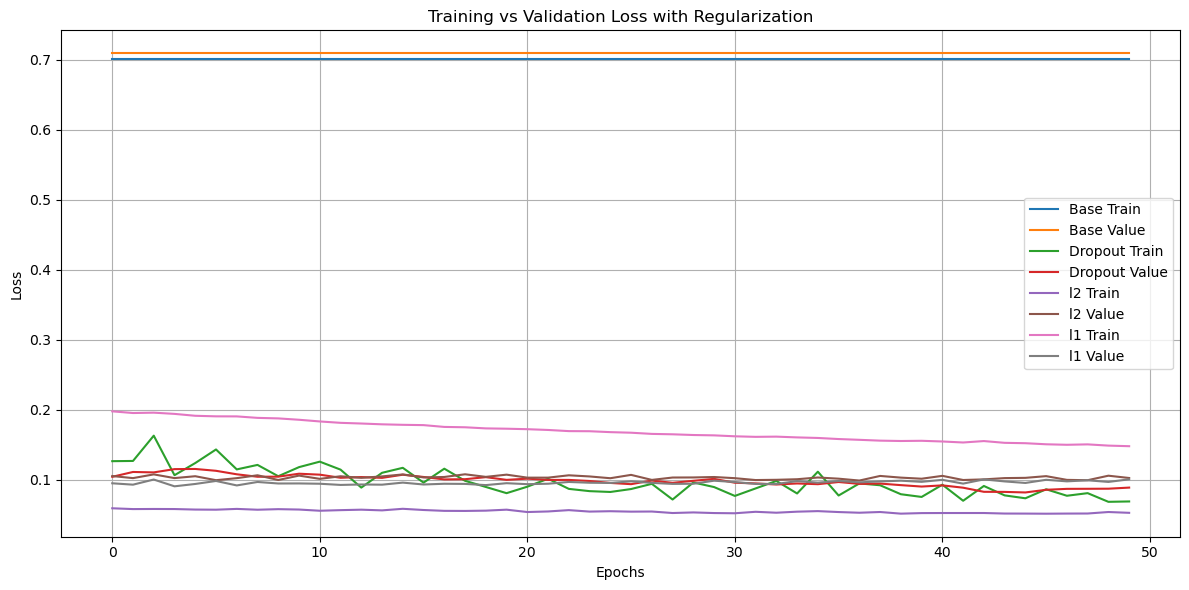

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(base_train, label='Base Train')
plt.plot(base_val, label="Base Value")
plt.plot(dropout_train, label = "Dropout Train")
plt.plot(dropout_val, label = "Dropout Value")
plt.plot(l2_train, label = "l2 Train")
plt.plot(l2_val, label = "l2 Value")
plt. plot(l1_train, label = "l1 Train")
plt.plot(l1_val, label = "l1 Value")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss with Regularization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()